In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

In [9]:
data =pd.read_csv('PlayTennis.csv')
data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [10]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
le = LabelEncoder()
for col in data.columns:
    data[col] = le.fit_transform(data[col])
data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1


In [11]:
x=data.drop(['Play Tennis'],axis=1)
y=data['Play Tennis']

In [12]:
clf_entropy =DecisionTreeClassifier(criterion='entropy',random_state=42)
clf_entropy.fit(x,y)
y_pred_entropy=clf_entropy.predict(x)

In [13]:
from sklearn.metrics import accuracy_score,classification_report
print("acc",accuracy_score(y,y_pred_entropy))
print("",classification_report(y,y_pred_entropy))


acc 1.0
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



[Text(0.4444444444444444, 0.9, 'Outlook <= 0.5\nentropy = 0.94\nsamples = 14\nvalue = [5, 9]\nclass = y[1]'),
 Text(0.3333333333333333, 0.7, 'entropy = 0.0\nsamples = 4\nvalue = [0, 4]\nclass = y[1]'),
 Text(0.38888888888888884, 0.8, 'True  '),
 Text(0.5555555555555556, 0.7, 'Humidity <= 0.5\nentropy = 1.0\nsamples = 10\nvalue = [5, 5]\nclass = y[0]'),
 Text(0.5, 0.8, '  False'),
 Text(0.3333333333333333, 0.5, 'Outlook <= 1.5\nentropy = 0.722\nsamples = 5\nvalue = [4, 1]\nclass = y[0]'),
 Text(0.2222222222222222, 0.3, 'Wind <= 0.5\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]\nclass = y[0]'),
 Text(0.1111111111111111, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = y[0]'),
 Text(0.3333333333333333, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = y[1]'),
 Text(0.4444444444444444, 0.3, 'entropy = 0.0\nsamples = 3\nvalue = [3, 0]\nclass = y[0]'),
 Text(0.7777777777777778, 0.5, 'Wind <= 0.5\nentropy = 0.722\nsamples = 5\nvalue = [1, 4]\nclass = y[1]'),
 Text(0.66666666666

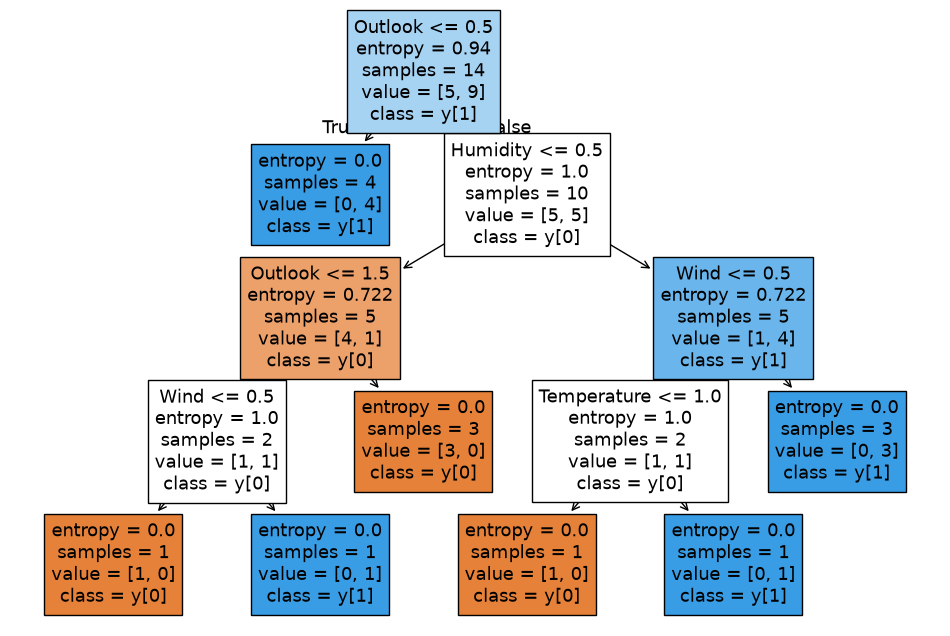

In [14]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(clf_entropy, filled=True,feature_names=x.columns,class_names=True)